<a href="https://colab.research.google.com/github/MuhammadNihalImran/ML_Lab_Tasks/blob/main/ML_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

#**Task 1: Simple Linear Regression:**

##**Load dataset:** Use the Diabetes dataset from sklearn.datasets. Select one feature (bmi) to predict the target (disease progression).

In [78]:
from sklearn.datasets import load_diabetes

In [79]:
diabetes_data = load_diabetes()
df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target
df.sample(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
328,-0.038207,-0.044642,0.067085,-0.060756,-0.029088,-0.023234,-0.010266,-0.002592,-0.001496,0.019633,78.0
421,0.038076,0.050680,0.016428,0.021872,0.039710,0.045032,-0.043401,0.071210,0.049770,0.015491,212.0
175,0.067136,-0.044642,-0.038540,-0.026328,-0.031840,-0.026366,0.008142,-0.039493,-0.027129,0.003064,127.0
334,-0.060003,0.050680,-0.047163,-0.022885,-0.071743,-0.057681,-0.006584,-0.039493,-0.062917,-0.054925,72.0
207,0.009016,-0.044642,0.045529,0.028758,0.012191,-0.013840,0.026550,-0.039493,0.046133,0.036201,202.0


In [80]:
new_df = df[['bmi','target']]
new_df.sample(5)

,bmi,target
226,-0.046085,77.0
437,0.019662,178.0
57,-0.063330,37.0
46,-0.011595,190.0
267,-0.000817,115.0


##Perform Exploratory Data Analysis (EDA):
* Plot scatter plot of BMI vs. Disease Progression.
* Check correlation.


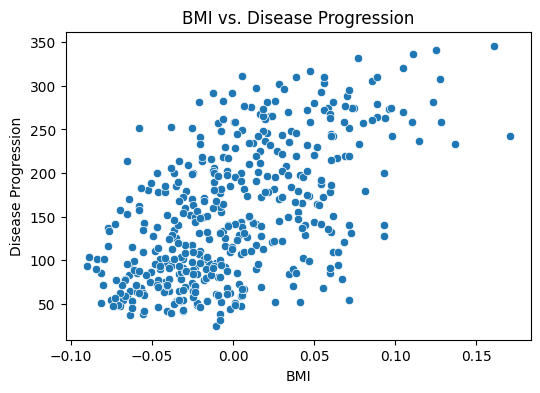

In [81]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=new_df, x='bmi', y='target')
plt.title('BMI vs. Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.show()

In [82]:
correlation = (df['bmi'].corr(df['target']))*100

print("Correlation between BMI and Disease Progression: %.2f%%" % correlation)

Correlation between BMI and Disease Progression: 58.65%


##Implement Simple Linear Regression using sklearn.linear_model.LinearRegression:
* Split data into training and testing sets.
* Fit the model and predict disease progression.
* Plot the regression line on the scatter plot.


In [83]:
from sklearn.model_selection import train_test_split

x =  df[['bmi']]
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [84]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


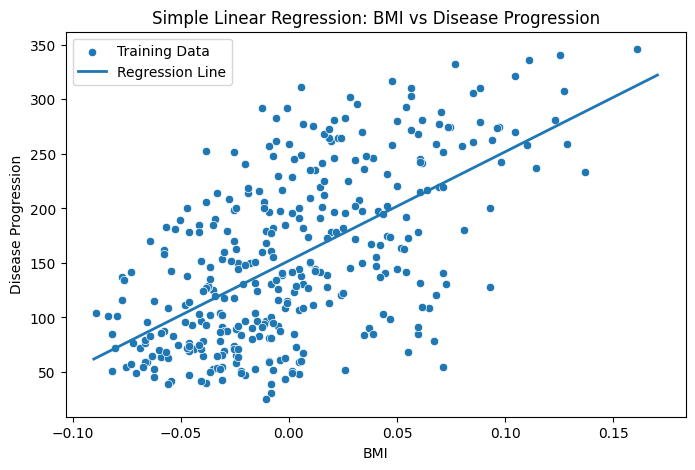

In [85]:
plt.figure(figsize=(8, 5))

# Actual data
sns.scatterplot(
    x=x_train['bmi'],
    y=y_train,
    label='Training Data'
)

# Regression line
x_line = np.linspace(
    x['bmi'].min(),
    x['bmi'].max(),
    100
).reshape(-1, 1)


y_line = model.predict(x_line)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title('Simple Linear Regression: BMI vs Disease Progression')

plt.legend()
plt.show()

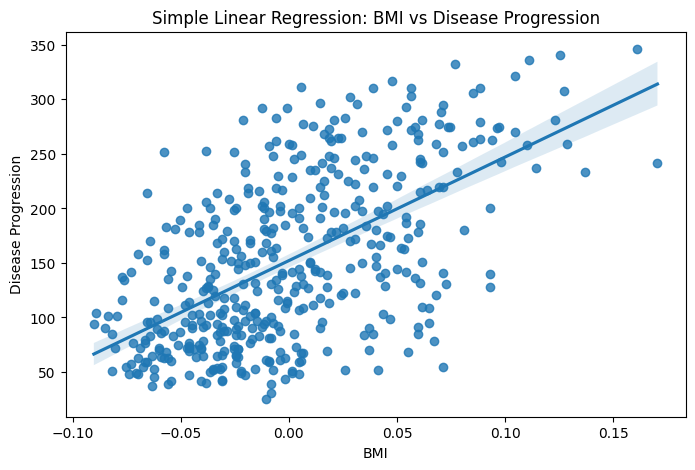

In [86]:
plt.figure(figsize=(8, 5))
sns.regplot(x='bmi', y='target', data=df)
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.show()

## Evaluate the model using:
* Mean Squared Error (MSE)
* R² score

In [87]:
from sklearn.metrics import mean_squared_error, r2_score

mse_simple = mean_squared_error(y_test, y_pred)
r2_simple = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse_simple}')
print(f'R² Score: {r2_simple}')

Mean Squared Error (MSE): 4061.8259284949268
R² Score: 0.23335039815872138


##Does BMI alone explain most of the variation in disease progression? How does R² help explain this?  
**No, BMI does not explain most of the changes in disease progression. The R² value is about 0.2, which means BMI explains only around 20% of the variation. The rest can be due to other factors and random variation. So, BMI can be useful for prediction, but it is not enough to predict disease progression accurately on its own.**


#**Task 2: Multivariate Linear Regression: -**


##**Load dataset:** Use the same Diabetes dataset, but include all 10 features to predict disease progression

In [88]:
from sklearn.datasets import load_diabetes
diabetes_data = load_diabetes()
df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target
print(df.shape)
df.sample(5)

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
333,0.027178,0.050680,-0.006206,0.028758,-0.016704,-0.001627,-0.058127,0.034309,0.029297,0.032059,164.0
286,-0.038207,-0.044642,-0.054707,-0.077970,-0.033216,-0.086490,0.140681,-0.076395,-0.019198,-0.005220,60.0
410,-0.009147,0.050680,-0.027762,0.008101,0.047965,0.037203,-0.028674,0.034309,0.066051,-0.042499,209.0
417,-0.052738,-0.044642,0.071397,-0.074527,-0.015328,-0.001314,0.004460,-0.021412,-0.046883,0.003064,55.0
55,-0.041840,-0.044642,-0.049318,-0.036656,-0.007073,-0.022608,0.085456,-0.039493,-0.066490,0.007207,128.0


##Perform EDA:
* Generate a correlation heatmap between features and the target.
* Create pair plots for selected features vs. target.

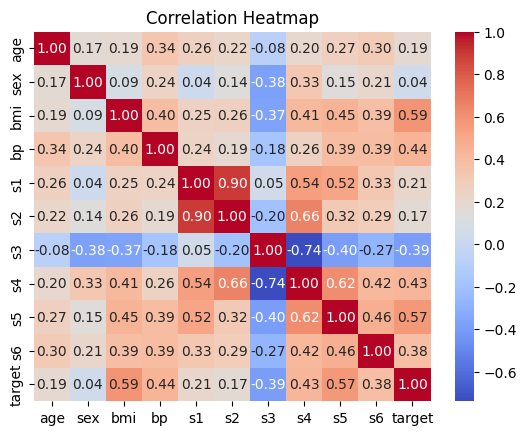

In [89]:
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f'
            )
plt.title('Correlation Heatmap')
plt.show()

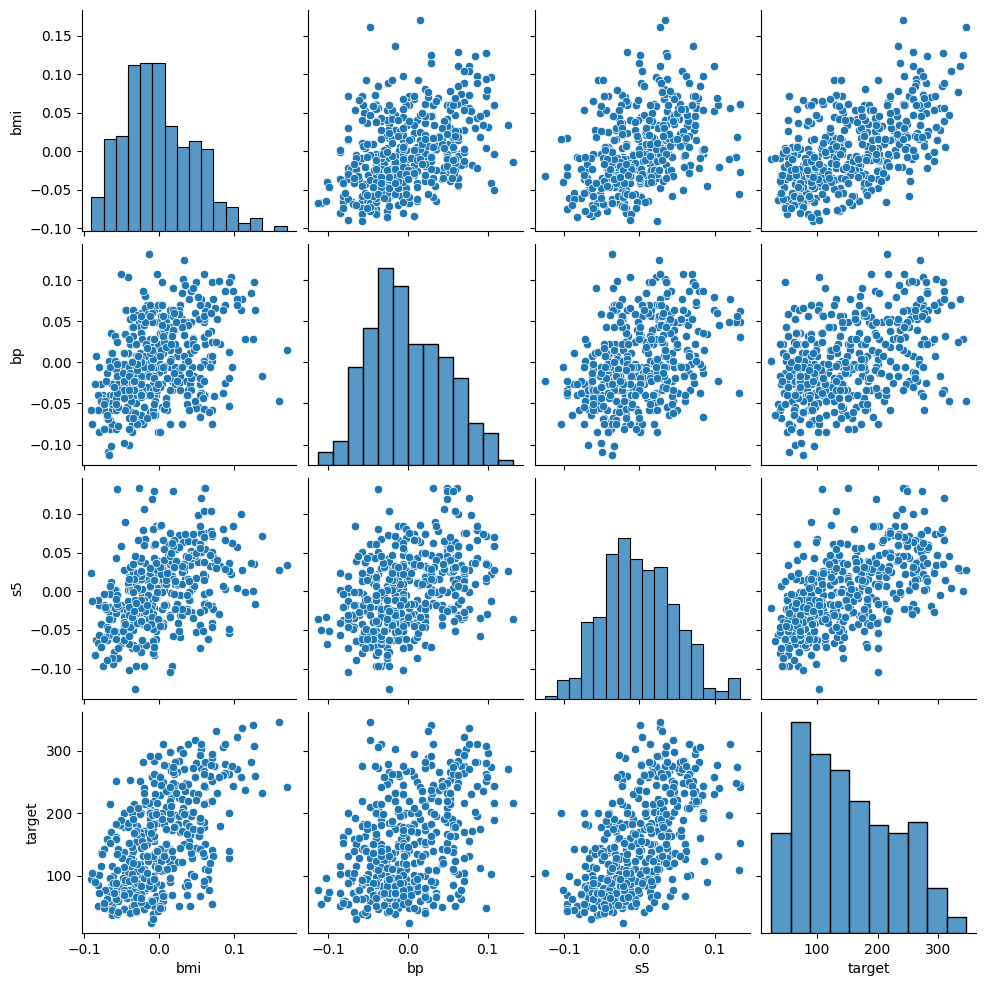

In [90]:
selected_features = ['bmi', 'bp', 's5', 'target']

sns.pairplot(
    df[selected_features]
)

plt.show()

## Implement Multivariate Linear Regression:
* Use all independent variables to predict the target.
* Fit and predict using the model.

In [91]:
from sklearn.model_selection import train_test_split

x = df.drop('target', axis=1)
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

## Compare actual vs. predicted values using:
* Scatter plot (predicted vs. actual).
* Residual plot

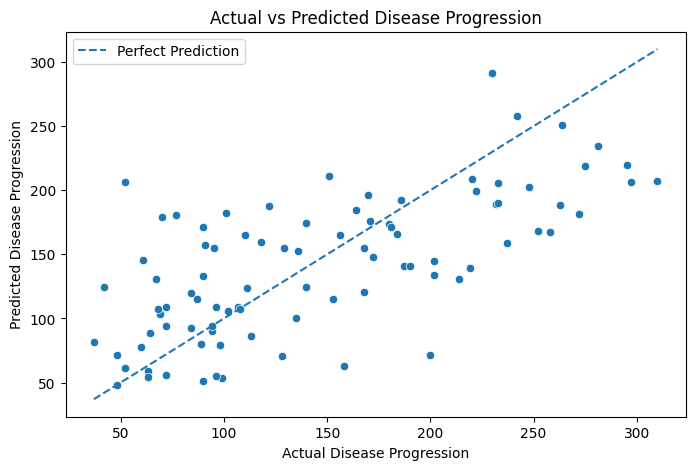

In [93]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.title('Actual vs Predicted Disease Progression')

plt.legend()
plt.show()


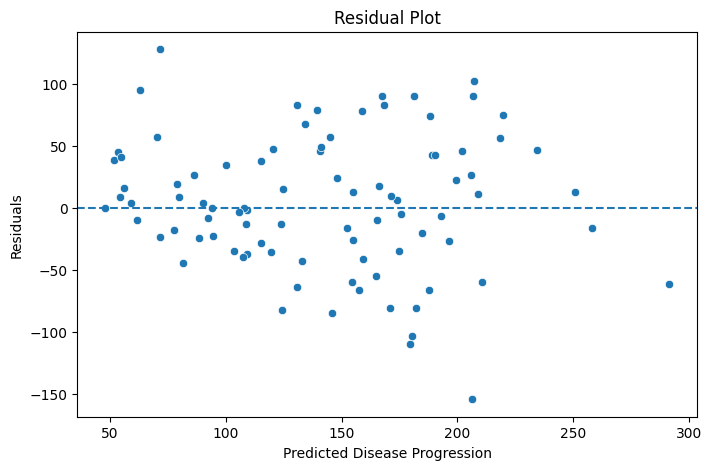

In [94]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Disease Progression')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()


##Evaluate model performance with:
* MSE
* RMSE
* R² score


In [95]:
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')

Mean Squared Error (MSE): 2900.193628493482
Root Mean Squared Error (RMSE): 53.85344583676593
R² Score: 0.4526027629719195


##**Which independent variable contributes the most to predicting disease progression?**

In [96]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficients:")
print(coefficients)


Feature Coefficients:
  Feature  Coefficient
0     age    37.904021
1     sex  -241.964362
2     bmi   542.428759
3      bp   347.703844
4      s1  -931.488846
5      s2   518.062277
6      s3   163.419983
7      s4   275.317902
8      s5   736.198859
9      s6    48.670657


In [97]:
coefficients['Absolute_Coefficient'] = abs(
    coefficients['Coefficient']
)

most_important = coefficients.loc[
    coefficients['Absolute_Coefficient'].idxmax()
]

print(most_important)

Feature                         s1
Coefficient            -931.488846
Absolute_Coefficient    931.488846
Name: 4, dtype: object


##From the regression coefficients, **s1** has the biggest effect on disease progression because its coefficient is the largest in absolute value, around **-931.49**. The negative sign means that when s1 increases, the predicted disease progression tends to decrease, assuming the other variables stay the same.


#**Task 3: Experimentation: -**
* Compare performance of simple vs. multivariate regression in terms of evaluation metrics.

In [98]:
print("\n===== SIMPLE LINEAR REGRESSION =====")
print("MSE :", mse_simple)
print("R²  :", r2_simple)

print("\n===== MULTIVARIATE LINEAR REGRESSION =====")
print("MSE :", mse)
print("R²  :", r2)


===== SIMPLE LINEAR REGRESSION =====
MSE : 4061.8259284949268
R²  : 0.23335039815872138

===== MULTIVARIATE LINEAR REGRESSION =====
MSE : 2900.193628493482
R²  : 0.4526027629719195


**The multivariate linear regression model gives better results than the simple linear regression model. The simple model only uses BMI, while the multivariate model uses all 10 features. The multivariate model has lower MSE and RMSE, which means its prediction errors are smaller. It also has a higher R² value, meaning it explains the disease progression better. So, using all 10 features gives better predictions than using BMI alone.**
